In [83]:
#Import necessary libraries
import pandas as pd
from pathlib import Path



In [84]:
#Combine all json files into one dataframe
raw_dir = Path('../data/raw')
json_files = sorted(raw_dir.glob('*.json'))
print(f"Reading {len(json_files)} weekly files from {raw_dir}")

all_articles = [pd.read_json(f) for f in json_files]
df = pd.concat(all_articles, ignore_index=True)

df = df[['webTitle', 'webPublicationDate', 'webUrl', 'sectionName']].drop_duplicates(subset=['webUrl'])

#Convert to datetime BEFORE saving, so the CSV holds proper timestamps
df['webPublicationDate'] = pd.to_datetime(df['webPublicationDate'], errors='coerce')

df.to_csv(Path('../data/processed/energy_headlines.csv'), index=False)
df.head()

Reading 53 weekly files from ../data/raw


,webTitle,webPublicationDate,webUrl,sectionName
0,Can bears swing upside down and what colour is...,2025-08-02 06:00:04+00:00,https://www.theguardian.com/lifeandstyle/2025/...,Life and style
1,‘He was angry’: India admit wind-up strategy t...,2025-08-01 20:27:18+00:00,https://www.theguardian.com/sport/2025/aug/01/...,Sport
2,Starmer defends investment in wind turbines af...,2025-07-28 17:52:00+00:00,https://www.theguardian.com/politics/live/2025...,Politics
3,Neo-Nazi leader sentenced to 20 years for plot...,2025-08-08 05:01:20+00:00,https://www.theguardian.com/us-news/2025/aug/0...,US news
5,Elon Musk’s Tesla applies to supply electricit...,2025-08-10 15:35:25+00:00,https://www.theguardian.com/technology/2025/au...,Technology


In [85]:
#Sanity check the combined dataset
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Nulls per column:\n{df.isnull().sum()}")
print(f"Dtypes:\n{df.dtypes}")
df.head(5)

Shape: (279, 4)
Columns: ['webTitle', 'webPublicationDate', 'webUrl', 'sectionName']
Nulls per column:
webTitle              0
webPublicationDate    0
webUrl                0
sectionName           0
dtype: int64
Dtypes:
webTitle                              str
webPublicationDate    datetime64[us, UTC]
webUrl                                str
sectionName                           str
dtype: object


,webTitle,webPublicationDate,webUrl,sectionName
0,Can bears swing upside down and what colour is...,2025-08-02 06:00:04+00:00,https://www.theguardian.com/lifeandstyle/2025/...,Life and style
1,‘He was angry’: India admit wind-up strategy t...,2025-08-01 20:27:18+00:00,https://www.theguardian.com/sport/2025/aug/01/...,Sport
2,Starmer defends investment in wind turbines af...,2025-07-28 17:52:00+00:00,https://www.theguardian.com/politics/live/2025...,Politics
3,Neo-Nazi leader sentenced to 20 years for plot...,2025-08-08 05:01:20+00:00,https://www.theguardian.com/us-news/2025/aug/0...,US news
5,Elon Musk’s Tesla applies to supply electricit...,2025-08-10 15:35:25+00:00,https://www.theguardian.com/technology/2025/au...,Technology


In [86]:
#Load the processed data (parse_dates so the timestamps come back as datetimes, not strings)
df = pd.read_csv('../data/processed/energy_headlines.csv', parse_dates=['webPublicationDate'])
df.head(5)

,webTitle,webPublicationDate,webUrl,sectionName
0,Can bears swing upside down and what colour is...,2025-08-02 06:00:04+00:00,https://www.theguardian.com/lifeandstyle/2025/...,Life and style
1,‘He was angry’: India admit wind-up strategy t...,2025-08-01 20:27:18+00:00,https://www.theguardian.com/sport/2025/aug/01/...,Sport
2,Starmer defends investment in wind turbines af...,2025-07-28 17:52:00+00:00,https://www.theguardian.com/politics/live/2025...,Politics
3,Neo-Nazi leader sentenced to 20 years for plot...,2025-08-08 05:01:20+00:00,https://www.theguardian.com/us-news/2025/aug/0...,US news
4,Elon Musk’s Tesla applies to supply electricit...,2025-08-10 15:35:25+00:00,https://www.theguardian.com/technology/2025/au...,Technology


In [87]:
#Random sample of 100 rows to hand-label. random_state fixes the sample so it is reproducible.
gold = df.sample(n=100, random_state=42).copy()
gold['event_type'] = None
gold['region'] = None
print(f"Shape of the gold dataframe: {gold.shape}")
gold.head(5)

Shape of the gold dataframe: (100, 6)


,webTitle,webPublicationDate,webUrl,sectionName,event_type,region
30,Climate activists gather in New York for ‘Sun ...,2025-09-22 11:34:44+00:00,https://www.theguardian.com/us-news/2025/sep/2...,US news,None,None
126,New Australian carbon credit scheme for solar ...,2026-01-18 14:00:59+00:00,https://www.theguardian.com/australia-news/202...,Australia news,None,None
199,Japan confirms release of more oil reserves as...,2026-04-10 05:50:57+00:00,https://www.theguardian.com/world/2026/apr/10/...,World news,None,None
142,The Boy Who Harnessed the Wind review – Malawi...,2026-02-20 15:04:32+00:00,https://www.theguardian.com/stage/2026/feb/20/...,Stage,None,None
254,A solar-powered rubbish-eating boat? The vesse...,2026-06-12 11:00:44+00:00,https://www.theguardian.com/environment/2026/j...,Environment,None,None


In [88]:
#Save the gold dataframe to a CSV file
gold.to_csv('../data/labeled/gold_unlabeled.csv', index=False)

In [89]:
#Load the hand-labelled export from Excel
gold_labelled = pd.read_csv('../data/labeled/gold_labeled.csv')
gold_labelled['event_type'] = gold_labelled['event_type'].str.strip()
gold_labelled['region'] = gold_labelled['region'].str.strip()

#Excel reformatted the dates on export, so keep only the columns we edited and
#rejoin the original metadata from energy_headlines.csv on webUrl
gold_labelled = gold_labelled[['webUrl', 'event_type', 'region']].merge(df, on='webUrl', how='left')

#Validation: fail loudly rather than silently carrying bad labels into evaluation
EVENT_TYPES = {'heatwave', 'cold', 'storm', 'flood', 'drought', 'none'}
REGIONS = {'UK', 'Germany', 'France', 'Spain', 'Netherlands', 'Europe', 'other'}

assert len(gold_labelled) == 100, f"expected 100 rows, got {len(gold_labelled)}"
assert gold_labelled['webTitle'].notna().all(), "some rows failed to match energy_headlines.csv on webUrl"
assert set(gold_labelled['event_type']) <= EVENT_TYPES, set(gold_labelled['event_type']) - EVENT_TYPES
assert set(gold_labelled['region']) <= REGIONS, set(gold_labelled['region']) - REGIONS
print("All checks passed.")

#Save the canonical gold set (gold_labeled.csv stays as the untouched Excel export)
gold_labelled = gold_labelled[['webTitle', 'webPublicationDate', 'webUrl', 'sectionName', 'event_type', 'region']]
gold_labelled.to_csv('../data/labeled/gold.csv', index=False, encoding='utf-8-sig')
gold_labelled.head(5)

All checks passed.


,webTitle,webPublicationDate,webUrl,sectionName,event_type,region
0,Energy bills: UK government urged to launch ‘s...,2026-03-18 06:00:25+00:00,https://www.theguardian.com/money/2026/mar/18/...,Money,none,UK
1,Datacentres should be forced to invest in wind...,2026-05-12 05:16:37+00:00,https://www.theguardian.com/environment/2026/m...,Environment,none,other
2,"Knit pants, waterproof boots and more: 20 thin...",2026-01-27 16:17:38+00:00,https://www.theguardian.com/thefilter-us/2026/...,The Filter US,none,UK
3,Energy bills to rise more than expected for mi...,2025-08-27 12:07:47+00:00,https://www.theguardian.com/money/2025/aug/27/...,Money,none,UK
4,EU plans to cut electricity taxes to shield ho...,2026-04-22 12:48:36+00:00,https://www.theguardian.com/environment/2026/a...,Environment,none,Europe


## Class balance

Check the split before evaluating. With a large majority class, raw accuracy is misleading, so the model has to be scored per class.

Event type distribution:
event_type
none        98
heatwave     1
storm        1
Name: count, dtype: int64
Region distribution:
region
other     52
UK        43
Europe     5
Name: count, dtype: int64


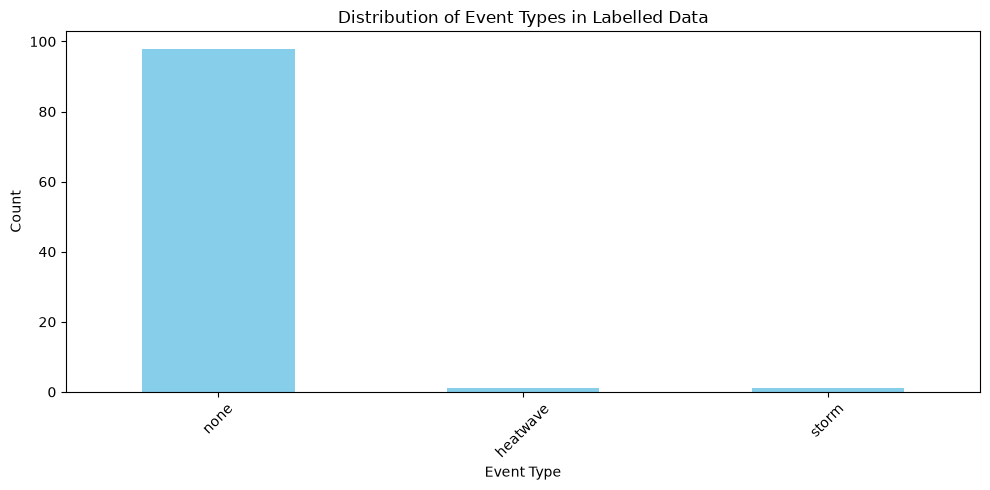

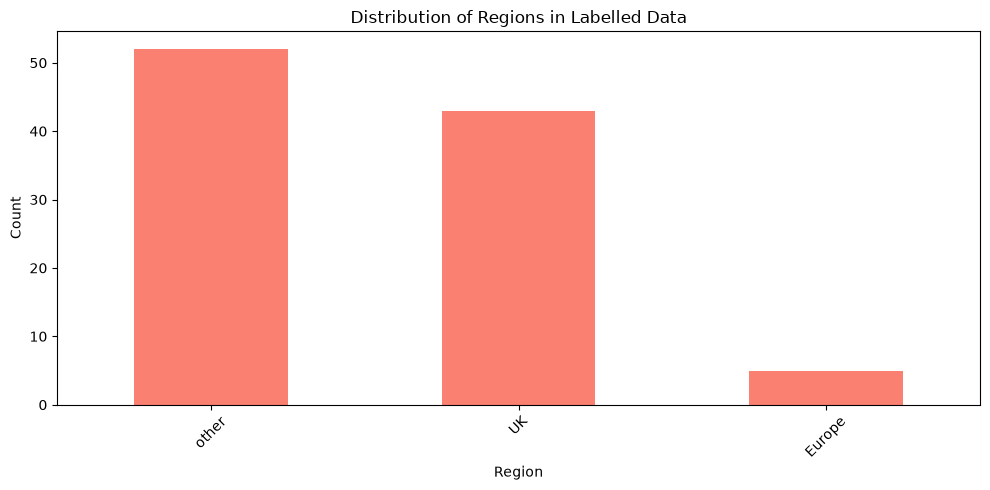

In [90]:
#Distribuition of event types and regions in the labelled data
event_type_distribution = gold_labelled['event_type'].value_counts()
region_distribution = gold_labelled['region'].value_counts()

print(f"Event type distribution:\n{event_type_distribution}")
print(f"Region distribution:\n{region_distribution}")

import matplotlib.pyplot as plt
#Plot the distribution of event types
plt.figure(figsize=(10, 5))
event_type_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution of Event Types in Labelled Data')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

plt.figure(figsize=(10, 5))
#Plot the distribution of regions
region_distribution.plot(kind='bar', color='salmon')
plt.title('Distribution of Regions in Labelled Data')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()


## Enriched weather sample

The random 100 contains only 2 weather events, too few to measure per-class accuracy. This second set comes from a weather-focused query (`src/ingest_weather.py`) and is used only to score `event_type`. It stays separate from the random 100, which remains the unbiased estimate of the live distribution.

In [91]:
#Combine the weather-focused pull
weather_dir = Path('../data/raw_weather')
weather = pd.concat([pd.read_json(f) for f in sorted(weather_dir.glob('*.json'))], ignore_index=True)
weather = weather[['webTitle', 'webPublicationDate', 'webUrl', 'sectionName']].drop_duplicates(subset=['webUrl'])
weather['webPublicationDate'] = pd.to_datetime(weather['webPublicationDate'], errors='coerce')

#Exclude anything already in the random 100 so the two sets never share rows
weather = weather[~weather['webUrl'].isin(gold_labelled['webUrl'])]
print(f"Weather pool after removing gold rows: {weather.shape}")
weather.head()

Weather pool after removing gold rows: (750, 4)


,webTitle,webPublicationDate,webUrl,sectionName
0,Nordic countries hit by ‘truly unprecedented’ ...,2025-08-02 09:00:07+00:00,https://www.theguardian.com/environment/2025/a...,Environment
1,Beware the blizzard of lies: US advice on how ...,2025-07-26 08:47:07+00:00,https://www.theguardian.com/politics/2025/jul/...,Politics
2,Weather tracker: Cooldown in sight for south-e...,2025-07-28 09:37:45+00:00,https://www.theguardian.com/environment/2025/j...,Environment
3,Eastern US swelters from heatwave as high temp...,2025-07-28 20:46:01+00:00,https://www.theguardian.com/us-news/2025/jul/2...,Environment
4,"UK has not hit ‘peak Greggs’, says CEO, as sal...",2025-07-29 12:05:53+00:00,https://www.theguardian.com/business/2025/jul/...,Business


In [92]:
#Sample 40 to hand-label
enriched = weather.sample(n=40, random_state=42).copy()
enriched['event_type'] = None
enriched['region'] = None
enriched.to_csv('../data/labeled/gold_enriched_unlabeled.csv', index=False, encoding='utf-8-sig')
print(f"Saved {enriched.shape[0]} rows to label")
enriched[['webTitle', 'sectionName']].head(10)

Saved 40 rows to label


,webTitle,sectionName
561,Cyclone Narelle forecast tracking map: where i...,Australia news
391,Australian Open insulates tennis from extreme ...,Sport
146,Raise £12bn in budget by extending income tax ...,UK news
276,Storm Bram: ‘danger to life’ warnings issued a...,UK news
329,Amsterdam airport cancels at least 800 flights...,World news
752,Dangerous temperatures forecast for parts of E...,Environment
368,Powerful winter storm to bring heavy snow acro...,US news
168,Hurricane Melissa hits Cuba after turning Jama...,World news
586,Lotte Wubben-Moy finds ‘perfect storm’ to show...,Football
814,Weather tracker: Flooding and landslides hit l...,Environment


### Validate and save the enriched set

Same checks as the random 100. The two sets stay in separate files: the random sample estimates performance on the live distribution, the enriched sample measures event classification where the classes are rare.

In [93]:
#Load the hand-labelled enriched export from Excel
df_enriched = pd.read_csv('../data/labeled/gold_enriched_labeled.csv')
df_enriched['event_type'] = df_enriched['event_type'].str.strip()
df_enriched['region'] = df_enriched['region'].str.strip()

#Keep only the columns edited by hand, rejoin clean metadata from the weather pool
df_enriched = df_enriched[['webUrl', 'event_type', 'region']].merge(weather, on='webUrl', how='left')

#Validation
assert len(df_enriched) == 40, f"expected 40 rows, got {len(df_enriched)}"
assert df_enriched['webTitle'].notna().all(), "some rows failed to match the weather pool on webUrl"
assert set(df_enriched['event_type']) <= EVENT_TYPES, set(df_enriched['event_type']) - EVENT_TYPES
assert set(df_enriched['region']) <= REGIONS, set(df_enriched['region']) - REGIONS
print("All checks passed.")

df_enriched = df_enriched[['webTitle', 'webPublicationDate', 'webUrl', 'sectionName', 'event_type', 'region']]
df_enriched.to_csv('../data/labeled/gold_enriched.csv', index=False, encoding='utf-8-sig')

print(f"Event types: {df_enriched['event_type'].value_counts().to_dict()}")
print(f"Regions: {df_enriched['region'].value_counts().to_dict()}")
df_enriched.head(5)

All checks passed.
Event types: {'none': 15, 'storm': 11, 'heatwave': 5, 'cold': 4, 'flood': 4, 'drought': 1}
Regions: {'other': 21, 'UK': 16, 'Europe': 2, 'Netherlands': 1}


,webTitle,webPublicationDate,webUrl,sectionName,event_type,region
0,Cyclone Narelle forecast tracking map: where i...,2026-03-27 05:39:18+00:00,https://www.theguardian.com/australia-news/202...,Australia news,storm,other
1,Australian Open insulates tennis from extreme ...,2026-01-27 01:08:03+00:00,https://www.theguardian.com/sport/2026/jan/27/...,Sport,heatwave,other
2,Raise £12bn in budget by extending income tax ...,2025-10-25 11:00:33+00:00,https://www.theguardian.com/uk-news/2025/oct/2...,UK news,none,UK
3,Storm Bram: ‘danger to life’ warnings issued a...,2025-12-09 14:27:54+00:00,https://www.theguardian.com/uk-news/live/2025/...,UK news,storm,UK
4,Amsterdam airport cancels at least 800 flights...,2026-01-07 16:03:50+00:00,https://www.theguardian.com/world/2026/jan/07/...,World news,cold,Netherlands
